# Bibliotecas

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from UQpy.run_model.RunModel import RunModel
from UQpy.run_model.model_execution.PythonModel import PythonModel
from UQpy.distributions import Uniform
from UQpy.distributions.collection.JointIndependent import JointIndependent
from UQpy.sensitivity.SobolSensitivity import SobolSensitivity
from UQpy.sensitivity.PostProcess import *

# Rodando a análise

In [20]:
# Construção do modelo
model = PythonModel(model_script="modelo.py", model_object_name="funcao_1", 
                    var_names=["$X_1$", "$X_2$", "$X_3$"], 
                    delete_files=True, params=[7, 0.1])
runmodel_obj = RunModel(model=model)

# Distribuições das variáveis de entrada
dist_object = JointIndependent([Uniform(-np.pi, 2 * np.pi)] * 3)

# Análise de sensibilidade
SA = SobolSensitivity(runmodel_obj, dist_object)
SA.run(n_samples=100_000, n_bootstrap_samples=200)

## Análise do índice de primeira ordem

In [21]:
SA.first_order_indices

array([[ 0.31503951],
       [ 0.44265532],
       [-0.00181035]])

## Análise do índice de segunda ordem

In [22]:
SA.total_order_indices

array([[0.55741639],
       [0.44199871],
       [0.23939054]])

# Gráficos

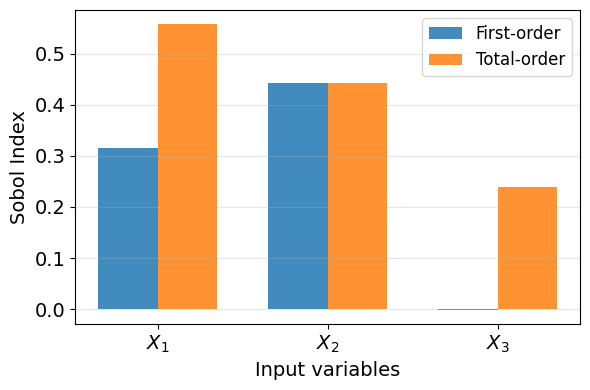

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Dados
first  = SA.first_order_indices[:, 0]
total  = SA.total_order_indices[:, 0]
labels = ["$X_1$", "$X_2$", "$X_3$"]

# Número de variáveis
n = len(labels)
x = np.arange(n)
width = 0.35  # largura das barras

plt.figure(figsize=(6, 4))

# Barras First-order
plt.bar(
    x - width/2,
    first,
    width,
    label="First-order",
    alpha=0.85
)

# Barras Total-order
plt.bar(
    x + width/2,
    total,
    width,
    label="Total-order",
    alpha=0.85
)

# Configurações
plt.xticks(x, labels, fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Input variables", fontsize=14)
plt.ylabel("Sobol Index", fontsize=14)

plt.legend(fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()    f"sobol_indices_figure.png",  
    dpi=600,                       
    bbox_inches="tight",
    pad_inches=0.05
)

plt.savefig(f"sobol_indices_figure.png", dpi=600, bbox_inches="tight", pad_inches=0.05)

plt.show()